### IID Uniform Sampling for Linear Region Count

#### Imports:

In [325]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

#### Code to generate iid uniform random sample:

In [2]:
def iid_uniform_sample(num_points,dimensions, lower_bounds, upper_bounds, rng):
    """Generates an iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: a random number generator used to ensure reproducibility of the sample
    Returns:
        points: 2D array of shape (num_points,dimensions) representing all the points
    """

    points = np.zeros((num_points,dimensions))
    for d in range(dimensions):
        sample = rng.uniform(lower_bounds[d],upper_bounds[d],num_points)
        points[:,d] = sample
    return points

Test function and display resulting sample:

In [58]:
num_points = 10000
dimensions = 2
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)
points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)

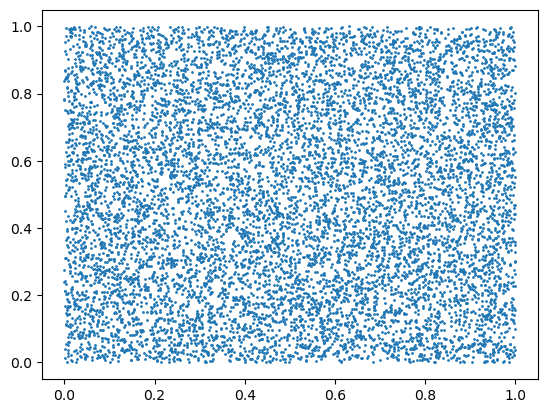

In [59]:
plt.scatter(points[:,0],points[:,1],s=1)

#### Code to set up MLP

Define class for a flexible MLP. It should allow the user to specify:
1. Dimension of the input space
2. Number of hidden neurons in each layer of the network (and therefore number of hidden layers)
3. Whether to use custom (user-provided) initial weights or to set them using Kaiming Normal Distribution (He initialisation)

In [5]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=False)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=False)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[i])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))
            

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 2D array of inputs of shape (batch size, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 2D array of shape: (batch size, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after linear layers
            if isinstance(layer,torch.nn.Linear):
                try:
                    activations = np.concatenate((activations,x.detach().numpy()),axis=1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x.detach().numpy()
        return activations

#### Code to count activation patterns/linear regions:

Create custom PyTorch dataset to process a batch of input points:

In [226]:
class SampleDataset(torch.utils.data.Dataset):
    """Custom dataset designed to store samples to be used in linear region counting"""

    def __init__(self, points):
        # self.points = array of samples of shape (num_points,input dimension)
        self.points = points
        
    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self,index):
        inputs = self.points[index,:]
        return inputs

Function to get numbers of unique linear regions after $N$ samples, $U(N)$:

In [265]:
def region_count(sample_data_loader,model):
    """Count the number of unique linear regions in the input space of a MLP using
    random sample of points from that input space

    Args:
        sample_data_loader: the data loader used to process the input data in batches
        model: the neural network model we are analysing
    Returns:
        unique_counts: a list of the number of regions found after each new sample
        samples_by_region: a dictionary containing each activation pattern and an array of input samples with that pattern
    """

    # Set list for the count after each sample
    # Set dictionary for the activation patterns and the samples corresponding to them
    unique_counts = []
    samples_by_region = {}

    for inputs in sample_data_loader:

        inputs = inputs.float()
        activations = model(inputs)

        # For each example in the batch
        for i in range(activations.shape[0]):

            # Get input point
            input_point = inputs[i,:].detach().numpy()

            # Get the activation pattern from the activation values
            example_values = activations[i,:]
            activation_pattern = ""
            for value in example_values:
                if value > 0:
                    activation_pattern += "1"
                else:
                    activation_pattern += "0"

            try:
                sample_points = samples_by_region[activation_pattern]
                sample_points = np.vstack((sample_points,input_point))
                samples_by_region[activation_pattern] = sample_points
                unique_counts.append(unique_counts[-1])
                
            except KeyError:

                if len(unique_counts)==0:
                    unique_counts.append(1)
                else:
                    unique_counts.append(unique_counts[-1]+1)

                samples_by_region[activation_pattern] = np.array([input_point])
                            
    return unique_counts, samples_by_region

#### Test: run code on simple neural network from first presentation and verify output

Put all the functions together to estimate linear region count in a simple neural network with a 2D input, single hidden layer, 2 hidden neurons and specific weights:

In [266]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)

model = MLP(dimensions,neurons_per_hidden,custom_weights)
points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
sample_dataset = SampleDataset(points)
sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
unique_counts, samples_by_region = region_count(sample_data_loader,model)

Plot the number of linear regions found in terms of the number of samples:

Text(0, 0.5, 'U(N)')

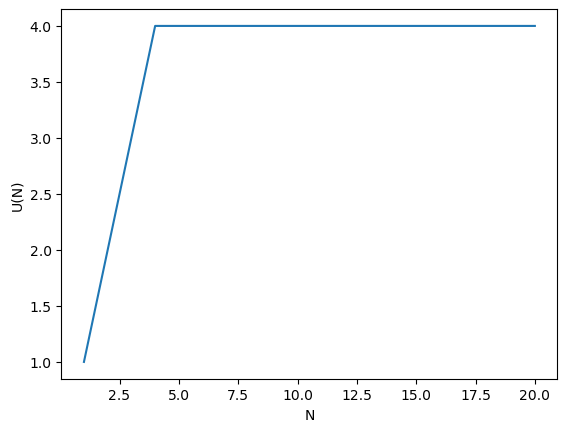

In [267]:
y = unique_counts[0:20]
x = np.arange(1,len(y)+1)
plt.plot(x,y)
plt.xlabel("N")
plt.ylabel("U(N)")

Text(0, 0.5, '$x_{2}$')

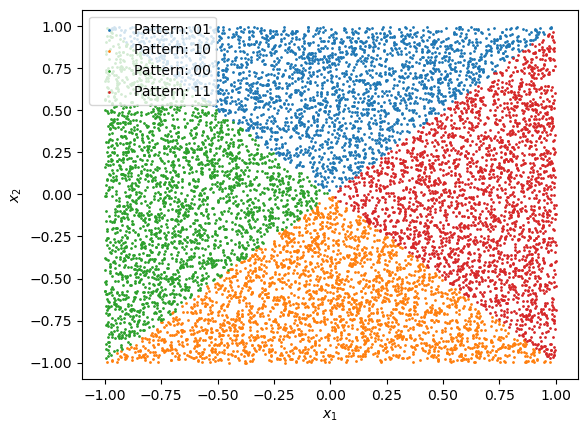

In [268]:
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.legend()
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

In this example:
- There are exactly 4 unique linear regions found, which is exactly what we expect from the theory
- The linear regions occupy 4 quadrants of the grid, and the patterns of each quadrant are exactly what we expect from the theory

This demonstrates that the MLP class and region counting function work correctly.

#### Variance + Dimension Experiments (NEW)

Below is a function for an experiment to determine how the variance of the linear regions depends on number of hidden layers and dimension of the input space:

In [295]:
def experiment_1(num_points, num_runs, neurons_per_hidden, dimensions):
    """Determine how variance of linear region count depends on number of hidden layers and dimension of input space.
    
    Args:
        num_points: the number of input points to randomly sample
        num_runs: the number of runs to calculate variance across
        neurons_per_hidden: the number of hidden neurons in each layer
        dimensions: the dimension of the input space
    Returns:
        total_unique_counts: the number of linear regions found after each sample
        variances: the run-to-run variance after each number of samples
        total_samples_by_region: the samples for each linear region for all 50 runs
    """

    example_runs = np.empty((len(dimensions),num_points))
    total_samples_by_region = []
    total_variances = []
    unique_counts_dimension = []
    
    for i in range(len(dimensions)):
    
        # Initialise the model
        lower_bounds = np.full(dimensions[i],-1)
        upper_bounds = np.full(dimensions[i],1)
        model = MLP(dimensions[i],neurons_per_hidden)
    
        total_unique_counts = np.empty((num_runs,num_points))
        
        for j in range(num_runs):
            rng = np.random.default_rng(seed=j)
            points = iid_uniform_sample(num_points,dimensions[i],lower_bounds,upper_bounds,rng)
            sample_dataset = SampleDataset(points)
            sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=256, shuffle=False)
            unique_counts, samples_by_region = region_count(sample_data_loader,model)
            total_unique_counts[j,:] = unique_counts
    
        variances = np.var(total_unique_counts,axis=0)
        total_samples_by_region.append(samples_by_region)
        total_variances.append(variances)
        unique_counts_dimension.append(total_unique_counts)
    
    return unique_counts_dimension, total_variances, total_samples_by_region

EXPERIMENT 1:
- 100000 samples
- 50 independent runs
- [5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [321]:
num_points = 100000
num_runs = 50
neurons_per_hidden = [5,5]
dimensions = [2,3,4,5,6,7,8,9,10]

unique_counts_dimension_a, total_variances_a, total_samples_by_region_a = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)

Text(0, 0.5, 'Maximum Variance')

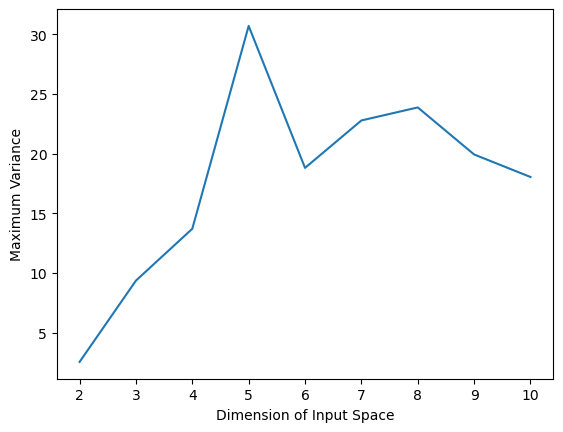

In [332]:
max_variances = [max(variance_array) for variance_array in total_variances_a]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

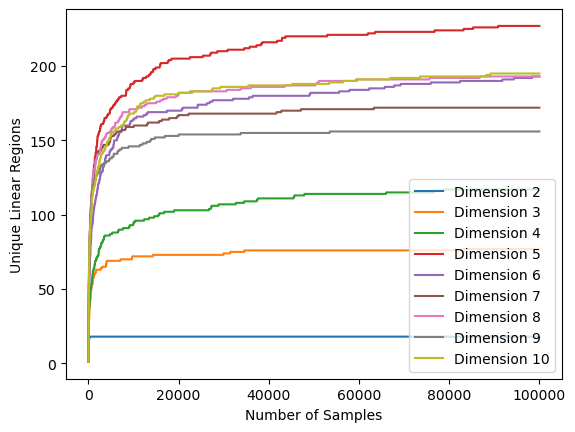

In [333]:
x = np.arange(100000)
i=0
for discovery_curves in unique_counts_dimension_a:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

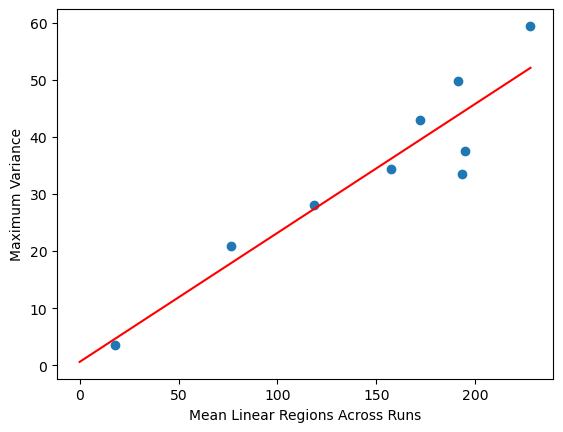

In [345]:
total_regions = [np.mean(unique_counts_dimension_a[i][:,-1]) for i in range(9)]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_var,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

EXPERIMENT 2:
- 1 million samples
- 50 independent runs
- [5,5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [322]:
num_points = 1000000
num_runs = 50
neurons_per_hidden = [5,5,5]
dimensions = [2,3,4,5,6,7,8,9,10]

unique_counts_dimension_b, total_variances_b, total_samples_by_region_b = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)

Text(0, 0.5, 'Maximum Variance')

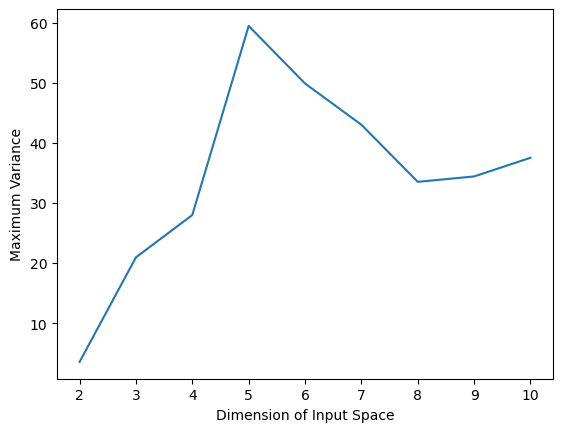

In [334]:
max_variances = [max(variance_array) for variance_array in total_variances_b]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

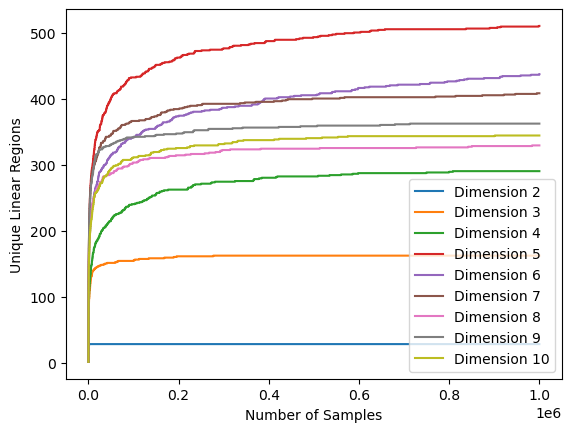

In [335]:
x = np.arange(1000000)
i=0
for discovery_curves in unique_counts_dimension_b:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

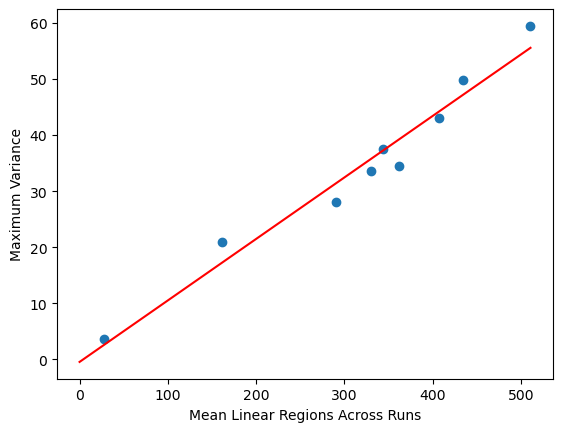

In [346]:
total_regions = [np.mean(unique_counts_dimension_b[i][:,-1]) for i in range(9)]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_var,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

EXPERIMENT 3:
- 10 million samples
- 50 independent runs
- [5,5,5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [360]:
num_points = 2000000
num_runs = 50
neurons_per_hidden = [5,5,5,5]
dimensions = [2,3,4,5,6,7,8,9,10]

start_time = time.time()
unique_counts_dimension_c, total_variances_c, total_samples_by_region_c = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_c = end_time - start_time

In [394]:
print(time_c)

22307.656975984573


Text(0, 0.5, 'Maximum Variance')

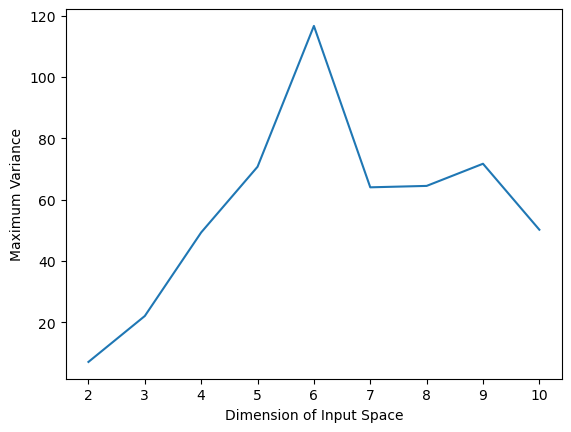

In [362]:
max_variances = [max(variance_array) for variance_array in total_variances_c]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

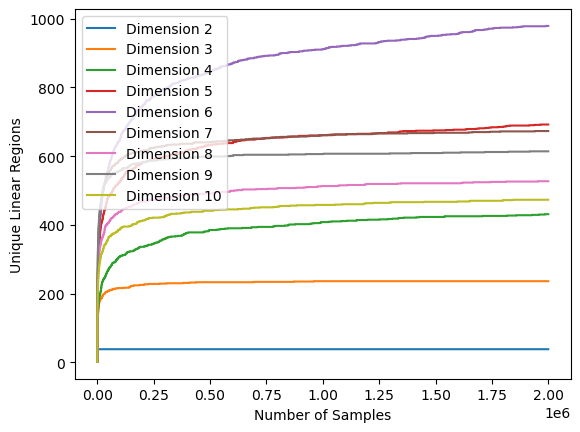

In [364]:
x = np.arange(2000000)
i=0
for discovery_curves in unique_counts_dimension_c:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

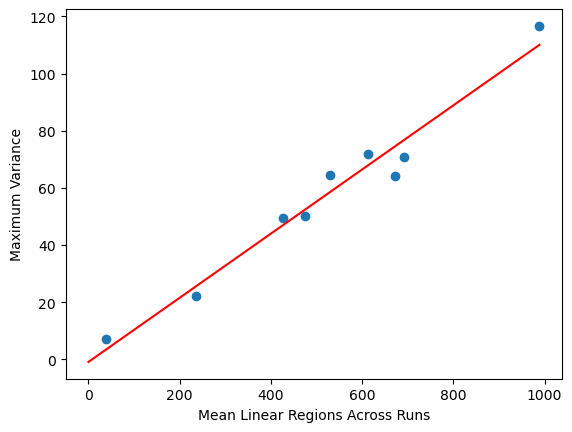

In [373]:
total_regions = [np.mean(unique_counts_dimension_c[i][:,-1]) for i in range(9)]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

EXPERIMENT 4:
- 10 million samples
- 50 independent runs
- [5,5,5,5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [361]:
num_points = 2000000
num_runs = 50
neurons_per_hidden = [5,5,5,5,5]
dimensions = [2,3,4,5,6,7,8,9,10]

start_time = time.time()
unique_counts_dimension_d, total_variances_d, total_samples_by_region_d = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_d = end_time - start_time

In [392]:
print(time_d)

24810.69019794464


Text(0, 0.5, 'Maximum Variance')

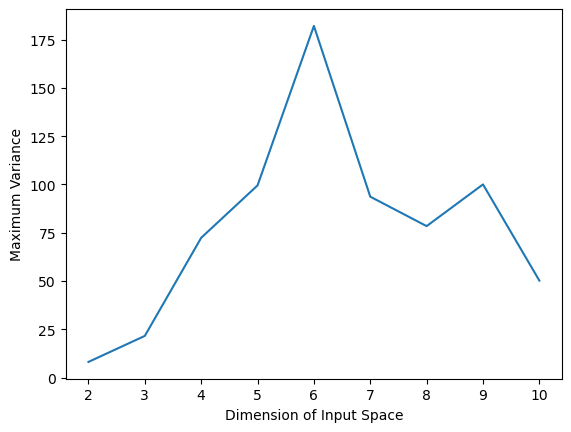

In [374]:
max_variances = [max(variance_array) for variance_array in total_variances_d]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

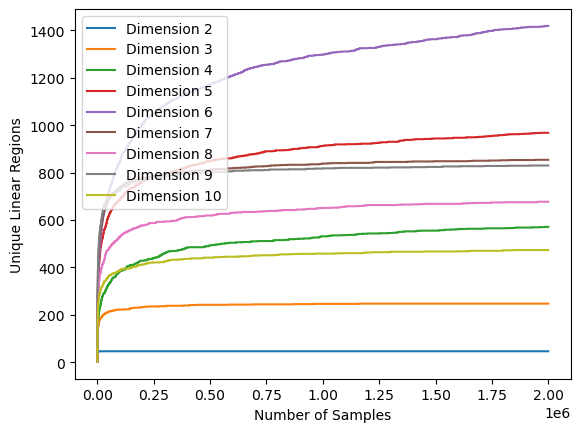

In [375]:
x = np.arange(2000000)
i=0
for discovery_curves in unique_counts_dimension_d:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

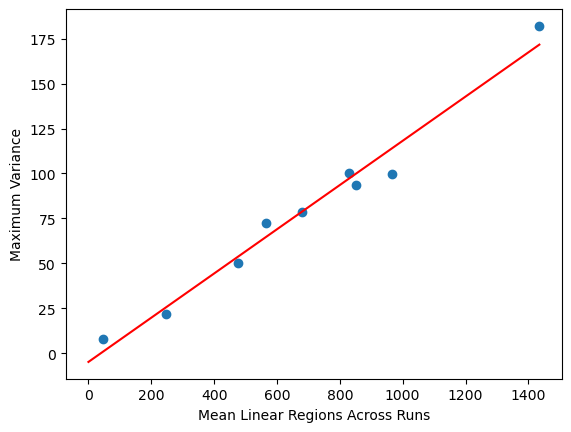

In [376]:
total_regions = [np.mean(unique_counts_dimension_d[i][:,-1]) for i in range(9)]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

SAVE DATA:

- Save all the arrays from the experiments to .npy files for loading later

In [383]:
np.save("counts_a.npy",unique_counts_dimension_a)
np.save("variances_a.npy",total_variances_a)
np.save("samples_by_region_a.npy",total_samples_by_region_a)

In [384]:
np.save("counts_b.npy",unique_counts_dimension_b)
np.save("variances_b.npy",total_variances_b)
np.save("samples_by_region_b.npy",total_samples_by_region_b)

In [385]:
np.save("counts_c.npy",unique_counts_dimension_c)
np.save("variances_c.npy",total_variances_c)
np.save("samples_by_region_c.npy",total_samples_by_region_c)

In [386]:
np.save("counts_d.npy",unique_counts_dimension_d)
np.save("variances_d.npy",total_variances_d)
np.save("samples_by_region_d.npy",total_samples_by_region_d)

#### Investigate saturation time

Instead of using a fixed number of samples, we can try to come up with a metric to identify when the counting process has effectively stopped and there is not going to be a significant increase in the number of regions.

IDEA 1: Stop counting if number of regions does not improve after $n$ samples
- Counting process often stops and starts again, and the time for which it stops is dependent on the size of the network and number of regions, so it doesn't make sense to assign fixed $n$ for every network.

IDEA 2: Stop counting if the _fraction_ of new regions over the last $p$% of samples falls below a threshold
- This solves the above problem by taking into account an increasing timespan as the number of samples increases, and we tend to stagnate for longer periods of time as the number of samples used increases.
- At first, you should see a fraction close to 50% because there should be one new region for each sample, and it should go to 0 as time goes on because we should find new regions at a slower and slower rate.
- How to choose the threshold and $p$?

IDEA 3: Look at multiple independent runs and stop when the variance between runs falls below some threshold
- Computationally expensive because requires multiple runs
- How to choose number of runs and threshold?
- Hyperuniformity may not behave the same way in terms of variance, so it may not be possible to apply the same method for measuring the saturation time to hyperuniform samples.

Investigate IDEA 2:

In [454]:
def lag(unique_counts,p):
    """Compute the difference between the number of linear regions found over last p% of samples
    Args:
        unique_counts: the chain for the number of unique regions found after each number of samples
        p: the percentage of the chain to consider the lag over
    Returns:
        lags: the fraction of samples counted within the last 50% of the chain
    """

    lags = []
    for i in range(2,len(unique_counts)+1):
        lag = (unique_counts[i-1] - unique_counts[int(i-p*i/100)-1])/unique_counts[i-1]
        lags.append(lag)

    return lags

Plot the lag (fraction of linear regions counted over the last 50% of samples) for the different dimensions, as well as the threshold value (10% of the original number):

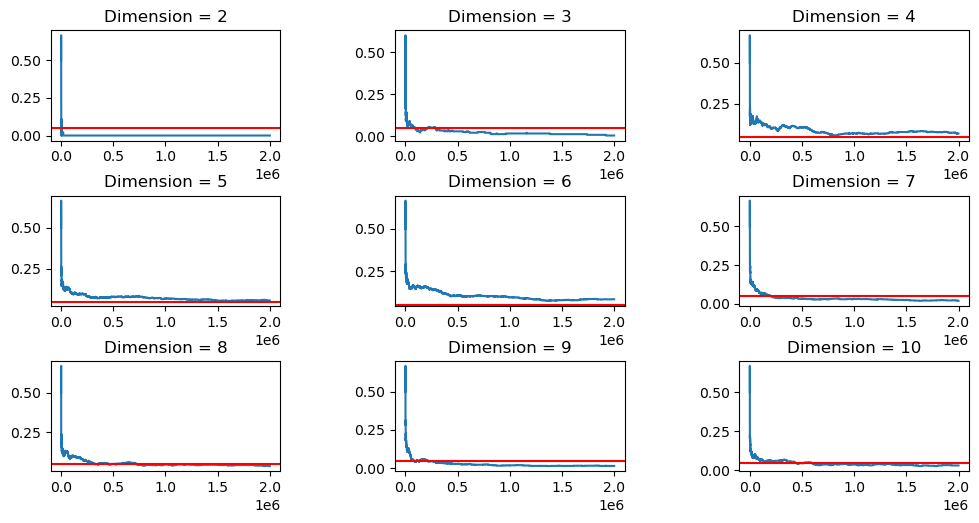

In [455]:
dimensions = [2,3,4,5,6,7,8,9,10]
crossing_points = []
fig,axs = plt.subplots(3,3,figsize=(10,5))
fig.tight_layout()

for dimension in dimensions:
    
    unique_counts = unique_counts_dimension_d[dimension-2][0,:]
    lags = lag(unique_counts,50)
    x = np.arange(len(lags))
    threshold = 0.1*lags[0]
    values_below = np.where(np.array(lags)<threshold)
    if len(values_below[0]>0):
        crossing_points.append(values_below[0][0])
    else:
        crossing_points.append(None)
        
    if dimension <= 4:
        axs[0,dimension-2].plot(x,lags)
        axs[0,dimension-2].axhline(threshold,color="red")
        axs[0,dimension-2].set_title(f"Dimension = {dimension}")
    elif dimension <= 7:
        axs[1,dimension-5].plot(x,lags)
        axs[1,dimension-5].axhline(threshold,color="red")
        axs[1,dimension-5].set_title(f"Dimension = {dimension}")
    else:
        axs[2,dimension-8].plot(x,lags)
        axs[2,dimension-8].axhline(threshold,color="red")
        axs[2,dimension-8].set_title(f"Dimension = {dimension}")
        
plt.subplots_adjust(wspace=0.5,hspace=0.5)

Identify sample where the fraction drops below the threshold:

In [456]:
for i in range(len(dimensions)):
    print(f"Dimension {dimensions[i]}: {crossing_points[i]}")

Dimension 2: 112
Dimension 3: 86008
Dimension 4: None
Dimension 5: None
Dimension 6: None
Dimension 7: 192466
Dimension 8: 349392
Dimension 9: 77588
Dimension 10: 438984


Comparing the estimated saturation points with the discovery curves showing the number of unique regions over time, these saturation points seem fairly reasonable (for example dimension 2 and 3 saturate very quickly which is what we would expect, and dimension 4,5 and 6 do not saturate at all, which makes sense as the discovery curve keeps on increasing instead of flattening out).

#### Investigate location of linear regions

Look at distribution of number of samples for each linear region -> should tell us roughly about the relative size of the regions:

46
245
557
959
1441
855
674
829
476


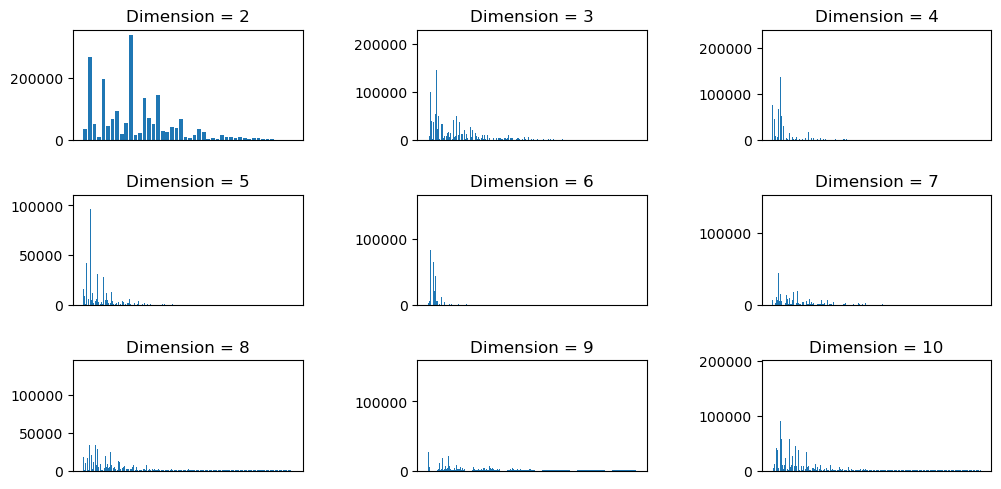

In [465]:
dimensions = [2,3,4,5,6,7,8,9,10]
fig,axs = plt.subplots(3,3,figsize=(10,5))
fig.tight_layout()

for dimension in dimensions:
    
    samples_by_region = total_samples_by_region_d[dimension-2]
    patterns = samples_by_region.keys()
    print(len(patterns))
    counts = [len(samples_by_region[key]) for key in patterns]
    if dimension <= 4:
        axs[0,dimension-2].bar(patterns,counts)
        axs[0,dimension-2].set_title(f"Dimension = {dimension}")
        axs[0,dimension-2].set_xticks([])
        axs[0,dimension-2].get_xaxis().set_visible(False)
    elif dimension <= 7:
        axs[1,dimension-5].bar(patterns,counts)
        axs[1,dimension-5].set_title(f"Dimension = {dimension}")
        axs[1,dimension-5].set_xticks([])
        axs[1,dimension-5].get_xaxis().set_visible(False)
    else:
        axs[2,dimension-8].bar(patterns,counts)
        axs[2,dimension-8].set_title(f"Dimension = {dimension}")
        axs[2,dimension-8].set_xticks([])
        axs[2,dimension-8].get_xaxis().set_visible(False)
        
plt.subplots_adjust(wspace=0.5,hspace=0.5)

The plots above show that the number of samples for each region is more even for dimension 2 and 3, and becomes much less even for dimensions 4, 5 and 6. This suggests that there are a couple of large regions and many small regions for these dimensions. For dimensions 7, 8, 9 and 10, the distribution appears to become more even again, which suggests a large number of more similar-sized regions.

In the 2D case, we can use our `samples_by_region` data to plot the mean position of the samples corresponding to each linear region:

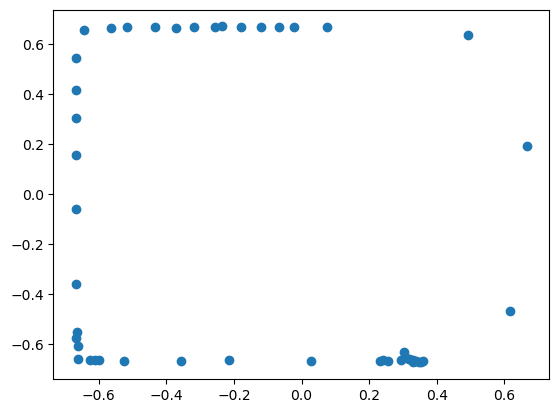

In [484]:
twoD_data = total_samples_by_region_d[0]
x_means = []
y_means = []
for key in twoD_data.keys():
    mean = np.mean(twoD_data[key],axis=0)
    x_means.append(mean[0])
    y_means.append(mean[1])
plt.scatter(x_means,y_means)

Plot the samples individually:

Text(0, 0.5, '$x_{2}$')

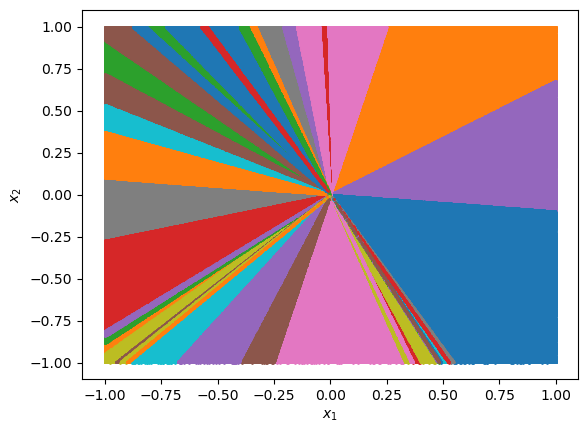

In [485]:
for pattern in twoD_data.keys():
    samples = twoD_data[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

#### Experiment to test variance of sampling (OLD)

Consider a neural network with 5 hidden layers and 20 hidden neurons per layer. We will repeat the experiment to count numbers of linear regions 30 times, taking a new set of random samples each time, and calculate the variance after taking each number of samples.

In [10]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [20,20,20,20,20]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
model = MLP(dimensions,neurons_per_hidden)

num_runs = 30
total_unique_counts = np.empty((num_runs,num_points))

for i in range(num_runs):
    rng = np.random.default_rng(seed=i)
    points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
    sample_dataset = SampleDataset(points)
    sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
    unique_counts, all_patterns = region_count(sample_data_loader,model)
    total_unique_counts[i,:] = unique_counts

Text(0, 0.5, 'Unique Linear Regions')

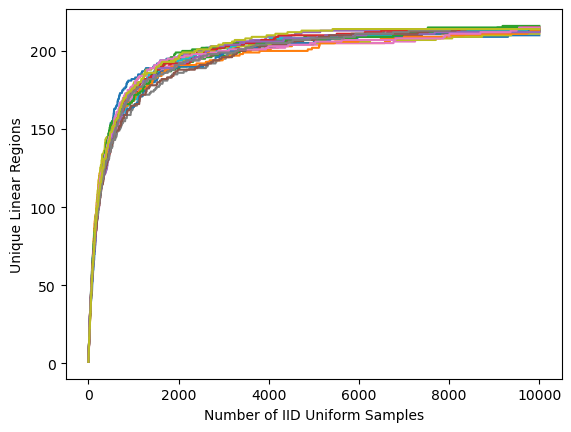

In [11]:
x = np.arange(1,total_unique_counts.shape[1]+1)
for i in range(1,20):
    plt.plot(x,total_unique_counts[i,:])
plt.xlabel("Number of IID Uniform Samples")
plt.ylabel("Unique Linear Regions")

In [12]:
variances = np.var(total_unique_counts, axis=0)

Text(0, 0.5, 'Variance in Linear Region Count')

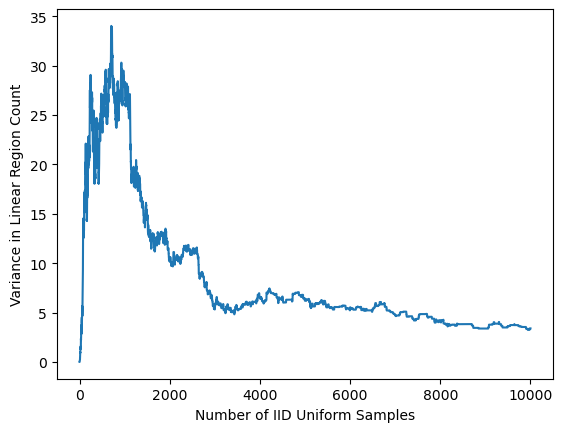

In [13]:
plt.plot(x,variances)
plt.xlabel("Number of IID Uniform Samples")
plt.ylabel("Variance in Linear Region Count")

This shows that the variance goes up rapidly at the start and comes down gradually as the number of samples increases, which is as expected.

Rerun the experiment using 3D input space:

N.B. Played around a bit with the number of samples and neurons per hidden layer - may need to use a smaller neural network to start with for the problem to be tractable

In [92]:
num_points = 1000000
dimensions = 5
neurons_per_hidden = [5,5,5]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
model = MLP(dimensions,neurons_per_hidden)

num_runs = 30
total_unique_counts = np.empty((num_runs,num_points))

for i in range(num_runs):
    rng = np.random.default_rng(seed=i)
    points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
    sample_dataset = SampleDataset(points)
    sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=256, shuffle=False)
    unique_counts, all_patterns = region_count(sample_data_loader,model)
    total_unique_counts[i,:] = unique_counts

Text(0, 0.5, 'Unique Linear Regions')

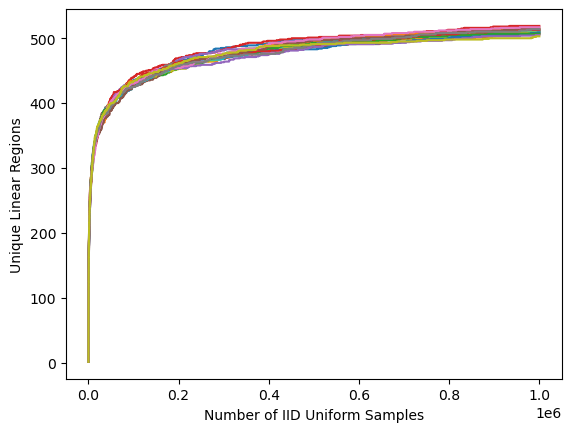

In [93]:
x = np.arange(1,total_unique_counts.shape[1]+1)
for i in range(1,20):
    plt.plot(x,total_unique_counts[i,:])
plt.xlabel("Number of IID Uniform Samples")
plt.ylabel("Unique Linear Regions")

In [94]:
variances = np.var(total_unique_counts, axis=0)

Text(0, 0.5, 'Variance in Linear Region Count')

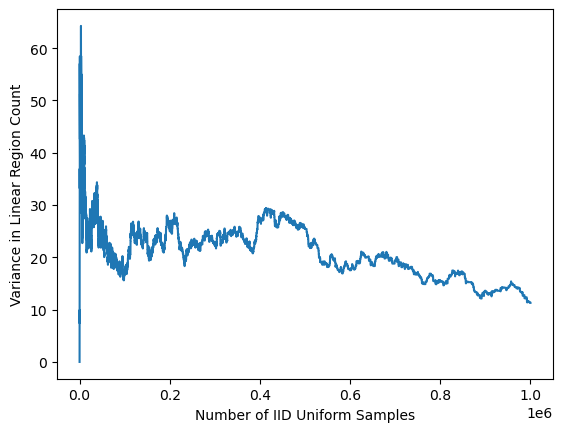

In [95]:
plt.plot(x,variances)
plt.xlabel("Number of IID Uniform Samples")
plt.ylabel("Variance in Linear Region Count")

These graphs look very different. The number of linear regions does not stop increasing after 10000 samples, and the variance does not reach a clear peak. This indicates that the saturation point has not been reached (or is just about being reached).

Difficulty with defining the saturation time:
- Could define it such that the number of linear regions does not increase for a certain number of iterations
- But often you end up not improving the count for a while, and then the count starts improving again
- The larger the network and the more linear regions there are, the longer the gaps between finding linear regions gets before you actually reach saturation
- So perhaps definition of saturation time should depend on how many linear regions have been found rather than be fixed? More linear regions found means we need to wait longer to consider the network to be saturated
  

To find a good definition of saturation time, plot the increase in linear regions over last 100 iterations against iterations:

In [208]:
x = np.arange(100,1000000)
additional_counts = []
for i in range(100,1000000):
    additional_counts.append(unique_counts[i-1]-unique_counts[i-int(0.5*i)])

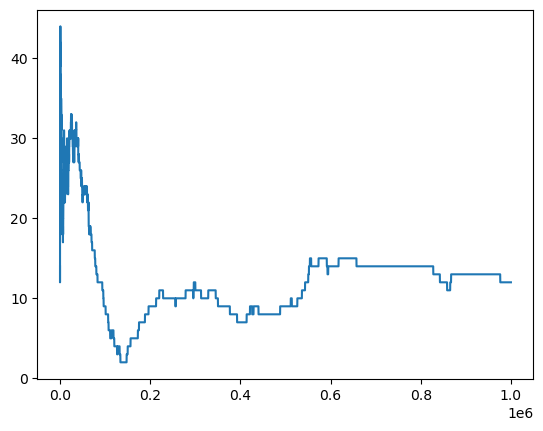

In [209]:
plt.plot(x,additional_counts)

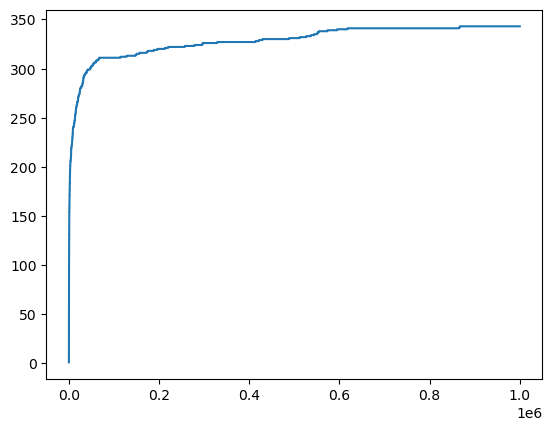

In [210]:
other_x = np.arange(1000000)
plt.plot(other_x,unique_counts)

#### Experiment to test increasing dimension (OLD)

We will repeat the above experiment, except we will also change the input dimension. We will look at how the maximum variance and mean variance change as the input dimension is increased:

In [141]:
num_points = 1000000
neurons_per_hidden = [5,5,5]

dimensions = [2,3,4,5,6,7,8,9,10]
num_runs = 50
max_var = []
mean_var = []
mean_counts = []
example_runs = np.empty((len(dimensions),num_points))
samples_until_saturation = []

for i in range(len(dimensions)):

    lower_bounds = np.full(dimensions[i],-1)
    upper_bounds = np.full(dimensions[i],1)
    model = MLP(dimensions[i],neurons_per_hidden)

    total_unique_counts = np.empty((num_runs,num_points))
    
    for j in range(num_runs):
        rng = np.random.default_rng(seed=j)
        points = iid_uniform_sample(num_points,dimensions[i],lower_bounds,upper_bounds,rng)
        sample_dataset = SampleDataset(points)
        sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=256, shuffle=False)
        unique_counts, all_patterns = region_count(sample_data_loader,model)
        total_unique_counts[j,:] = unique_counts
        
    # Calculate the maximum variance obtained across the entire run 
    example_runs[i,:] = total_unique_counts[0,:]
    mean_counts = np.mean(total_unique_counts[:,-1])
    variances = np.var(total_unique_counts,axis=0)
    max_var.append(max(variances))
    mean_var.append(np.mean(variances))

Text(0, 0.5, 'Maximum Variance')

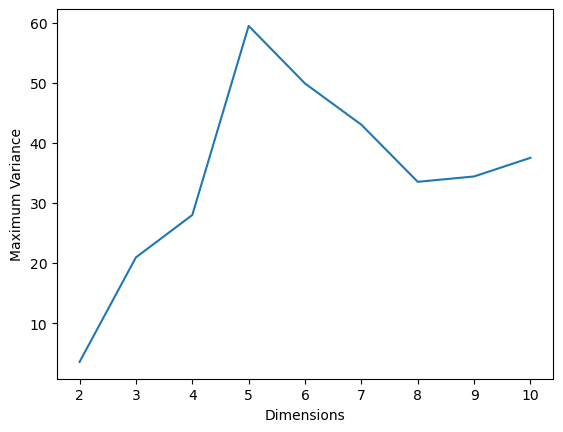

In [142]:
plt.plot(dimensions,max_var)
plt.xlabel("Dimensions")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Maximum Variance')

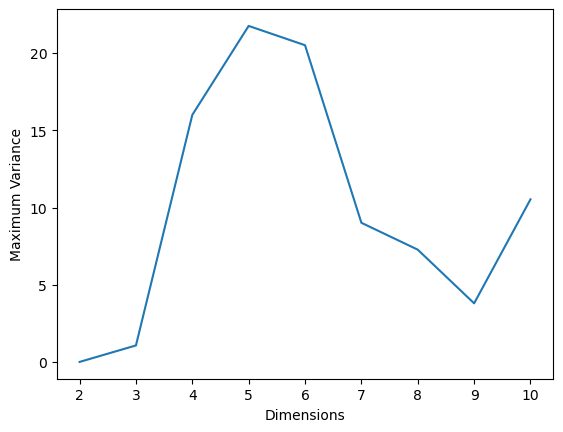

In [143]:
plt.plot(dimensions,mean_var)
plt.xlabel("Dimensions")
plt.ylabel("Maximum Variance")

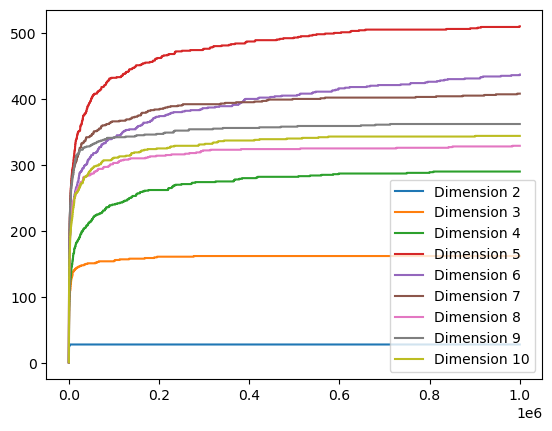

In [150]:
x = np.arange(1000000)
for i in range(len(dimensions)):
    plt.plot(x,example_runs[i,:],label=f"Dimension {i+2}")
plt.legend()

Text(0, 0.5, 'Additional Regions Found in last 50% of samples')

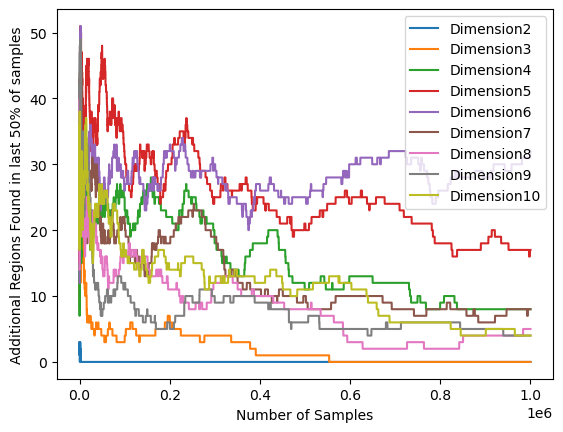

In [200]:
for j in range(len(dimensions)):
    run = example_runs[j,:]
    x = np.arange(100,1000000)
    additional_counts = []
    for i in range(100,1000000):
        additional_counts.append(run[i-1]-run[i-int(0.5*i)])
    plt.plot(x,additional_counts,label=f"Dimension{j+2}")
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Additional Regions Found in last 50% of samples")

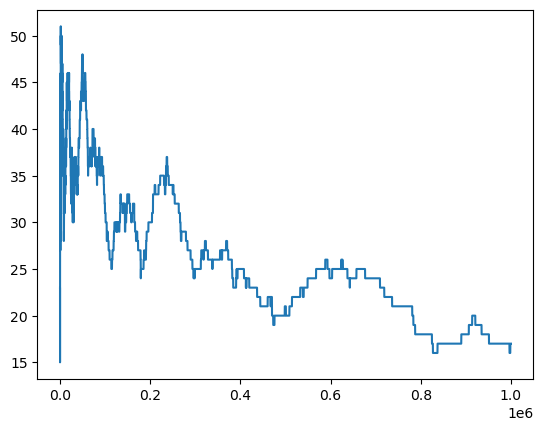

In [207]:
run = example_runs[3,:]
x = np.arange(100,1000000)
additional_counts = []
for i in range(100,1000000):
    additional_counts.append(run[i-1]-run[i-int(0.5*i)])
plt.plot(x,additional_counts)

Text(0, 0.5, 'Maximum Variance')

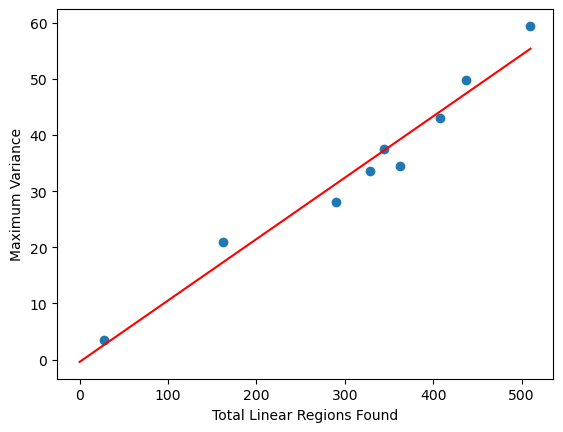

In [161]:
total_regions = example_runs[:,-1]
plt.scatter(total_regions,max_var)
coefs = np.polyfit(total_regions,max_var,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Total Linear Regions Found")
plt.ylabel("Maximum Variance")

Old graphs using NN with 20 neurons per layer and 5 layers:

Text(0, 0.5, 'Maximum Variance')

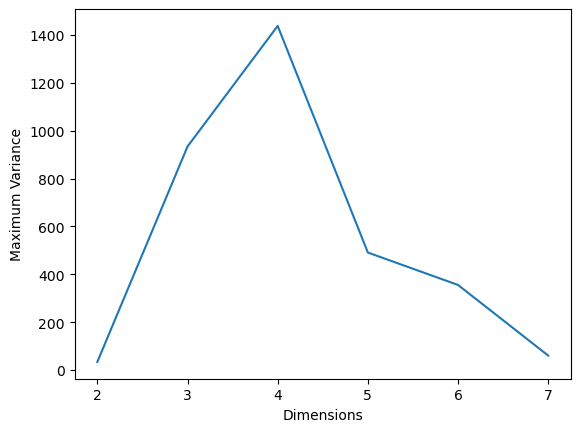

In [29]:
plt.plot(dimensions,max_var)
plt.xlabel("Dimensions")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Mean Variance')

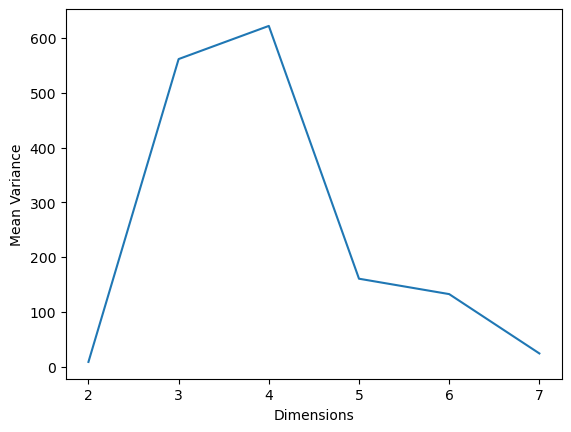

In [30]:
plt.plot(dimensions,mean_var)
plt.xlabel("Dimensions")
plt.ylabel("Mean Variance")

Why does the variance increase and then decrease again? Possible explanations:

- Plotting the discovery curve (unique linear regions against number of samples) indicates that the saturation point is not reached after 10000 samples for an input space dimension of 5 and above. The model is still in the early "linear" phase of the curve.
- NEXT TASK: Determine how saturation point depends on the input dimension (and then calculate the variance up to saturation rather than the variance after a fixed number of samples).